# Credit Risk Scoring Engine (V1 - Application Based)
Structured and documented version with additional feature engineering, feature importance and ROC curve.

In [1]:
# =========================
# 1. IMPORTS & DATA LOADING
# =========================
import pandas as pd
import numpy as np

app = pd.read_csv('dataset/application_record.csv')
credit = pd.read_csv('dataset/credit_record.csv')


In [2]:
# =========================
# 2. TARGET CREATION
# Customer is risky if status contains 2,3,4 or 5
# =========================
bad_status = ['2','3','4','5']

target = (
    credit.groupby('ID')['STATUS']
    .apply(lambda x: 1 if any(i in bad_status for i in x.astype(str)) else 0)
    .reset_index()
)

target.columns = ['ID','TARGET']
target.head()


,ID,TARGET
0,5001711,0
1,5001712,0
2,5001713,0
3,5001714,0
4,5001715,0


In [3]:
# =========================
# 3. MERGE APPLICATION + TARGET
# =========================
df = app.merge(target,on='ID',how='inner')
print(df.shape)


(36457, 19)


In [4]:
# =========================
# 4. BASIC CLEANING
# =========================

# FLAG_MOBIL has only one value -> no predictive power
df.drop('FLAG_MOBIL', axis=1, inplace=True)

# Missing occupation
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')

# Employment anomaly
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)


In [5]:
# =========================
# 5. FEATURE ENGINEERING
# =========================

df['AGE'] = (-df['DAYS_BIRTH']) // 365

df['IS_PENSIONER'] = (
    df['NAME_INCOME_TYPE'] == 'Pensioner'
).astype(int)

df['EMPLOYMENT_YEARS'] = (
    (-df['DAYS_EMPLOYED']) // 365
)

df['INCOME_PER_PERSON'] = (
    df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
)

# New Features
df['HAS_CHILDREN'] = (
    df['CNT_CHILDREN'] > 0
).astype(int)

df['CHILDREN_RATIO'] = (
    df['CNT_CHILDREN'] / df['CNT_FAM_MEMBERS']
)

df['LOG_INCOME'] = np.log1p(
    df['AMT_INCOME_TOTAL']
)

df['AGE_GROUP'] = pd.cut(
    df['AGE'],
    bins=[18,25,35,45,55,100],
    labels=['18_25','26_35','36_45','46_55','55_plus']
)


In [6]:
# Remove raw date columns after creating derived features
df.drop(
    columns=['DAYS_BIRTH','DAYS_EMPLOYED'],
    inplace=True
)


In [7]:
# =========================
# 6. ENCODING
# =========================

df['CODE_GENDER'] = df['CODE_GENDER'].map({'M':1,'F':0})
df['FLAG_OWN_CAR'] = df['FLAG_OWN_CAR'].map({'Y':1,'N':0})
df['FLAG_OWN_REALTY'] = df['FLAG_OWN_REALTY'].map({'Y':1,'N':0})

cat_cols = [
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'AGE_GROUP'
]

df_encoded = pd.get_dummies(
    df,
    columns=cat_cols,
    drop_first=True
)

df_encoded.drop('ID', axis=1, inplace=True)

print(df_encoded.shape)


(36457, 56)


In [8]:
# =========================
# 7. TRAIN TEST SPLIT
# =========================

X = df_encoded.drop('TARGET', axis=1)
y = df_encoded['TARGET']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(scale_pos_weight)


58.15821501014199


In [9]:
# =========================
# 8. XGBOOST MODEL
# =========================

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [10]:
# =========================
# 9. EVALUATION
# =========================

pred_xgb = xgb.predict(X_test)
prob_xgb = xgb.predict_proba(X_test)[:,1]

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

print(confusion_matrix(y_test, pred_xgb))
print(classification_report(y_test, pred_xgb))
print('ROC AUC =', roc_auc_score(y_test, prob_xgb))


[[6742  427]
 [  66   57]]
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      7169
           1       0.12      0.46      0.19       123

    accuracy                           0.93      7292
   macro avg       0.55      0.70      0.58      7292
weighted avg       0.98      0.93      0.95      7292

ROC AUC = 0.7072246472220616


In [11]:
# =========================
# 10. FEATURE IMPORTANCE
# =========================

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
})

importance.sort_values(
    'Importance',
    ascending=False
).head(20)


,Feature,Importance
14,CHILDREN_RATIO,0.024633
16,NAME_INCOME_TYPE_Pensioner,0.024297
10,IS_PENSIONER,0.023524
49,OCCUPATION_TYPE_Unknown,0.022589
27,NAME_FAMILY_STATUS_Widow,0.022369
51,AGE_GROUP_26_35,0.022350
35,OCCUPATION_TYPE_Core staff,0.022214
46,OCCUPATION_TYPE_Sales staff,0.022052
33,OCCUPATION_TYPE_Cleaning staff,0.021840
23,NAME_EDUCATION_TYPE_Secondary / secondary special,0.021835


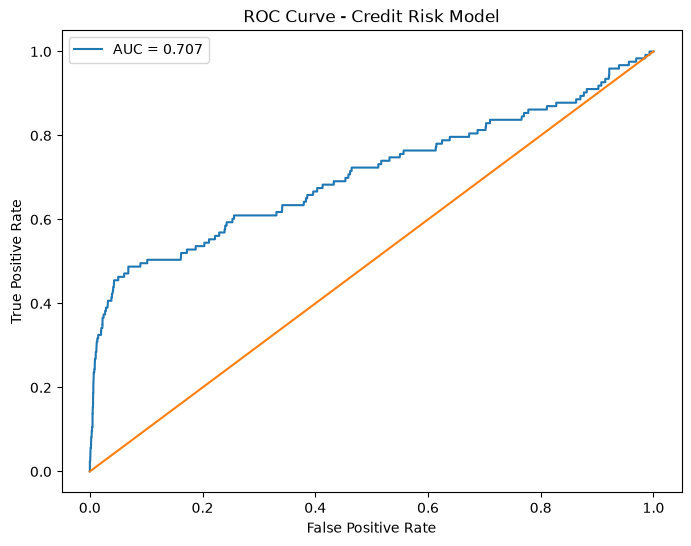

In [12]:
# =========================
# 11. ROC CURVE
# =========================

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, prob_xgb)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Credit Risk Model')
plt.legend()
plt.show()


# V2 - Behavioral Credit Risk Model

This section contains the behavioral-credit version developed using repayment history features:

- HISTORY_LENGTH
- CNT_C
- CNT_X
- CNT_0
- CNT_1
- CNT_2
- CNT_3
- CNT_4
- CNT_5
- MAX_STATUS_PAST
- HAS_EVER_BEEN_LATE

Add the final V2 implementation cells below this section.


In [19]:
def create_behavioral_dataset(credit_df):

    rows = []

    for customer_id, grp in credit_df.groupby('ID'):

        grp = grp.sort_values('MONTHS_BALANCE')

        if len(grp) < 12:
            continue

        past = grp.iloc[:12]
        future = grp.iloc[12:]

        if len(future) == 0:
            continue

        late_vals = [
            int(s)
            for s in past['STATUS'].astype(str)
            if s in ['1','2','3','4','5']
        ]

        rows.append({

            'ID': customer_id,

            'HISTORY_LENGTH': len(grp),

            'CNT_C': (past['STATUS'] == 'C').sum(),
            'CNT_X': (past['STATUS'] == 'X').sum(),
            'CNT_0': (past['STATUS'] == '0').sum(),
            'CNT_1': (past['STATUS'] == '1').sum(),
            'CNT_2': (past['STATUS'] == '2').sum(),
            'CNT_3': (past['STATUS'] == '3').sum(),
            'CNT_4': (past['STATUS'] == '4').sum(),
            'CNT_5': (past['STATUS'] == '5').sum(),

            'MAX_STATUS_PAST':
                max(late_vals) if len(late_vals) > 0 else 0,

            'HAS_EVER_BEEN_LATE':
                int(
                    past['STATUS']
                    .astype(str)
                    .isin(['1','2','3','4','5'])
                    .any()
                ),

            'TARGET':
                int(
                    future['STATUS']
                    .astype(str)
                    .isin(['1','2','3','4','5'])
                    .any()
                )
        })

    return pd.DataFrame(rows)

In [20]:
# Customers with at least 12 months history

hist_len = credit.groupby('ID').size()

eligible_ids = hist_len[
    hist_len >= 12
].index

credit_12 = credit[
    credit['ID'].isin(eligible_ids)
].copy()

print(credit_12['ID'].nunique())

32274


In [21]:
behavior_df = create_behavioral_dataset(credit_12)

print(behavior_df.shape)

print(
    behavior_df['TARGET']
    .value_counts()
)

(30918, 13)
TARGET
0    29179
1     1739
Name: count, dtype: int64


In [57]:
app_small = app[[
    'ID',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'CNT_CHILDREN',
    'AMT_INCOME_TOTAL',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'OCCUPATION_TYPE',
    'CNT_FAM_MEMBERS'
]].copy()

v2_df = behavior_df.merge(
    app_small,
    on='ID',
    how='left'
)

print(v2_df.shape)
print(v2_df.isnull().sum().sort_values(ascending=False).head(10))

(30918, 26)
OCCUPATION_TYPE       14660
DAYS_BIRTH             7499
FLAG_OWN_CAR           7499
NAME_INCOME_TYPE       7499
NAME_FAMILY_STATUS     7499
AMT_INCOME_TOTAL       7499
CNT_CHILDREN           7499
FLAG_OWN_REALTY        7499
CODE_GENDER            7499
NAME_HOUSING_TYPE      7499
dtype: int64


In [58]:
v2_df = v2_df.dropna(
    subset=['CODE_GENDER']
)

print(v2_df.shape)

(23419, 26)


In [59]:
# Missing occupation
v2_df['OCCUPATION_TYPE'] = (
    v2_df['OCCUPATION_TYPE']
    .fillna('Unknown')
)

# Employment anomaly
v2_df['DAYS_EMPLOYED'] = (
    v2_df['DAYS_EMPLOYED']
    .replace(365243, np.nan)
)

# Age
v2_df['AGE'] = (
    -v2_df['DAYS_BIRTH'] // 365
)

# Employment years
v2_df['EMPLOYMENT_YEARS'] = (
    -v2_df['DAYS_EMPLOYED'] // 365
)

# Pensioner
v2_df['IS_PENSIONER'] = (
    v2_df['NAME_INCOME_TYPE'] == 'Pensioner'
).astype(int)

# Income per family member
v2_df['INCOME_PER_PERSON'] = (
    v2_df['AMT_INCOME_TOTAL']
    / v2_df['CNT_FAM_MEMBERS']
)

# Log income
v2_df['LOG_INCOME'] = np.log1p(
    v2_df['AMT_INCOME_TOTAL']
)

# Children flag
v2_df['HAS_CHILDREN'] = (
    v2_df['CNT_CHILDREN'] > 0
).astype(int)

In [60]:
# Save IDs BEFORE dropping ID column
customer_ids = v2_df['ID'].copy()

v2_df = v2_df.drop(
    columns=[
        'ID',
        'DAYS_BIRTH',
        'DAYS_EMPLOYED'
    ]
)

In [61]:
cat_cols = [
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE'
]

v2_encoded = pd.get_dummies(
    v2_df,
    columns=cat_cols,
    drop_first=True
)

print(v2_encoded.shape)

(23419, 59)


In [62]:
v2_encoded['EMPLOYMENT_YEARS'] = (
    v2_encoded['EMPLOYMENT_YEARS']
    .fillna(0)
)

In [63]:
from sklearn.model_selection import train_test_split

X = v2_encoded.drop('TARGET', axis=1)
y = v2_encoded['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(scale_pos_weight)

17.066538090646095


In [64]:
from xgboost import XGBClassifier

xgb_v2 = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=17,
    random_state=42,
    eval_metric='logloss'
)

xgb_v2.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [65]:
pred_v2 = xgb_v2.predict(X_test)
prob_v2 = xgb_v2.predict_proba(X_test)[:,1]

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print(confusion_matrix(y_test, pred_v2))
print(classification_report(y_test, pred_v2))
print("ROC AUC =", roc_auc_score(y_test, prob_v2))

[[4104  321]
 [  97  162]]
              precision    recall  f1-score   support

           0       0.98      0.93      0.95      4425
           1       0.34      0.63      0.44       259

    accuracy                           0.91      4684
   macro avg       0.66      0.78      0.69      4684
weighted avg       0.94      0.91      0.92      4684

ROC AUC = 0.9036467944942521


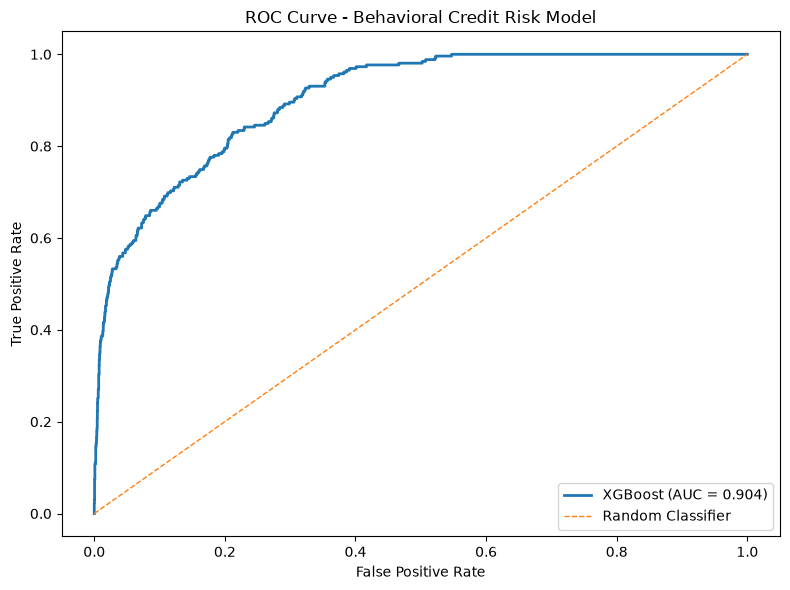

In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, prob_v2)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'XGBoost (AUC = {roc_auc:.3f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    linewidth=1,
    label='Random Classifier'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Behavioral Credit Risk Model")
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [67]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_v2.feature_importances_
})

importance.sort_values(
    'Importance',
    ascending=False
).head(20)

,Feature,Importance
1,CNT_C,0.481980
9,MAX_STATUS_PAST,0.074240
10,HAS_EVER_BEEN_LATE,0.069197
2,CNT_X,0.012281
40,OCCUPATION_TYPE_Cleaning staff,0.011847
49,OCCUPATION_TYPE_Managers,0.010794
19,HAS_CHILDREN,0.010309
0,HISTORY_LENGTH,0.009987
46,OCCUPATION_TYPE_IT staff,0.008698
17,INCOME_PER_PERSON,0.008245


# Experiment - Removing Most Dominant Feature

Objective:

Evaluate model robustness by removing the most important feature identified during feature importance analysis.

Suggested Documentation:

- Dominant Feature Removed: CNT_C
- Accuracy Before:0.91
- Accuracy After:0.91
- ROC-AUC Before:0.9
- ROC-AUC After:0.89
- Observations: NO LEAKAGE


In [41]:
X2 = v2_encoded.drop(
    columns=[
        'TARGET',
        'CNT_C'
    ]
)

y2 = v2_encoded['TARGET']

In [42]:
from sklearn.model_selection import train_test_split

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2,
    y2,
    test_size=0.2,
    random_state=42,
    stratify=y2
)

In [43]:
scale_pos_weight = (
    y2_train.value_counts()[0]
    /
    y2_train.value_counts()[1]
)

print(scale_pos_weight)

17.066538090646095


In [44]:
from xgboost import XGBClassifier

xgb_no_c = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_no_c.fit(X2_train, y2_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [45]:
pred_no_c = xgb_no_c.predict(X2_test)
prob_no_c = xgb_no_c.predict_proba(X2_test)[:,1]

from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y2_test, pred_no_c))
print("ROC AUC =", roc_auc_score(y2_test, prob_no_c))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      4425
           1       0.33      0.58      0.42       259

    accuracy                           0.91      4684
   macro avg       0.65      0.76      0.69      4684
weighted avg       0.94      0.91      0.92      4684

ROC AUC = 0.8927818860022251


# Job Conversion / Production Layer

Document:

- Model serialization
- Credit score generation
- Risk band logic
- Coloum required for Model


In [52]:
all_prob = xgb_v2.predict_proba(X)[:,1]

score_df = pd.DataFrame({
    'PD': all_prob
})

score_df.head()

score_df['PERCENTILE'] = (
    score_df['PD']
    .rank(pct=True)
)

score_df['CREDIT_SCORE'] = (
    900 - (score_df['PERCENTILE'] * 600)
).round().astype(int)

In [53]:
def risk_band(score):

    if score >= 800:
        return "Low Risk"

    elif score >= 700:
        return "Medium Risk"

    elif score >= 600:
        return "High Risk"

    else:
        return "Very High Risk"

score_df['RISK_BAND'] = (
    score_df['CREDIT_SCORE']
    .apply(risk_band)
)

In [54]:
score_df['RISK_BAND'].value_counts()

score_df['CREDIT_SCORE'].describe()

count    23419.000000
mean       599.986379
std        173.209621
min        300.000000
25%        450.000000
50%        600.000000
75%        750.000000
max        900.000000
Name: CREDIT_SCORE, dtype: float64

In [69]:
final_scores = pd.DataFrame({
    'ID': customer_ids.values,
    'PROBABILITY_OF_DEFAULT': all_prob,
    'CREDIT_SCORE': score_df['CREDIT_SCORE'].values,
    'RISK_BAND': score_df['RISK_BAND'].values
})

final_scores.head()

final_scores.to_csv(
    "customer_credit_scores.csv",
    index=False
)

print("Saved Successfully")
print(final_scores.shape)

Saved Successfully
(23419, 4)


In [70]:
import joblib

joblib.dump(
    xgb_v2,
    "credit_risk_model.pkl"
)

print("Model Saved")

joblib.dump(
    X.columns.tolist(),
    "feature_columns.pkl"
)

print("Columns Saved")

Model Saved
Columns Saved


In [71]:
print(X.columns.tolist())

['HISTORY_LENGTH', 'CNT_C', 'CNT_X', 'CNT_0', 'CNT_1', 'CNT_2', 'CNT_3', 'CNT_4', 'CNT_5', 'MAX_STATUS_PAST', 'HAS_EVER_BEEN_LATE', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'CNT_FAM_MEMBERS', 'AGE', 'EMPLOYMENT_YEARS', 'IS_PENSIONER', 'INCOME_PER_PERSON', 'LOG_INCOME', 'HAS_CHILDREN', 'CODE_GENDER_M', 'FLAG_OWN_CAR_Y', 'FLAG_OWN_REALTY_Y', 'NAME_INCOME_TYPE_Pensioner', 'NAME_INCOME_TYPE_State servant', 'NAME_INCOME_TYPE_Student', 'NAME_INCOME_TYPE_Working', 'NAME_EDUCATION_TYPE_Higher education', 'NAME_EDUCATION_TYPE_Incomplete higher', 'NAME_EDUCATION_TYPE_Lower secondary', 'NAME_EDUCATION_TYPE_Secondary / secondary special', 'NAME_FAMILY_STATUS_Married', 'NAME_FAMILY_STATUS_Separated', 'NAME_FAMILY_STATUS_Single / not married', 'NAME_FAMILY_STATUS_Widow', 'NAME_HOUSING_TYPE_House / apartment', 'NAME_HOUSING_TYPE_Municipal apartment', 'NAME_HOUSING_TYPE_Office apartment', 'NAME_HOUSING_TYPE_Rented apartment', 'NAME_HOUSING_TYPE_With parents', 'OCCUPATION_TYPE_Cleaning staff', 'OCCUPATION_T